In [5]:
!pip install yfinance

In [1]:
import pandas as pd
import yfinance as yf
from sklearn.model_selection import train_test_split, cross_val_score

def load_market_data(ticker="AAPL", start="2022-01-01", end="2023-01-01"):
    data = yf.download(ticker, start=start, end=end)
    return data

market_data = load_market_data()
market_data.columns = ["Close", "High", "Low",	"Open",	"Volume"]
market_data["Return"] = market_data["Close"].pct_change()

# Moving averages
market_data['SMA50'] = market_data['Close'].rolling(window=50).mean()
market_data['SMA200'] = market_data['Close'].rolling(window=200).mean()

market_data = market_data.dropna()

X_train, X_test, y_train, y_test = train_test_split(market_data.loc[:, ~market_data.columns.isin(['Return'])], market_data['Return'], test_size=0.2, shuffle=False)

# Use the same data for both strategies
signal_based_data = X_test.copy()
model_based_data = market_data.copy()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


# Signal-Based

Signal-Based Strategy Accuracy: 63.64%
Signal-Based Strategy Cumulative Return: 4.68%


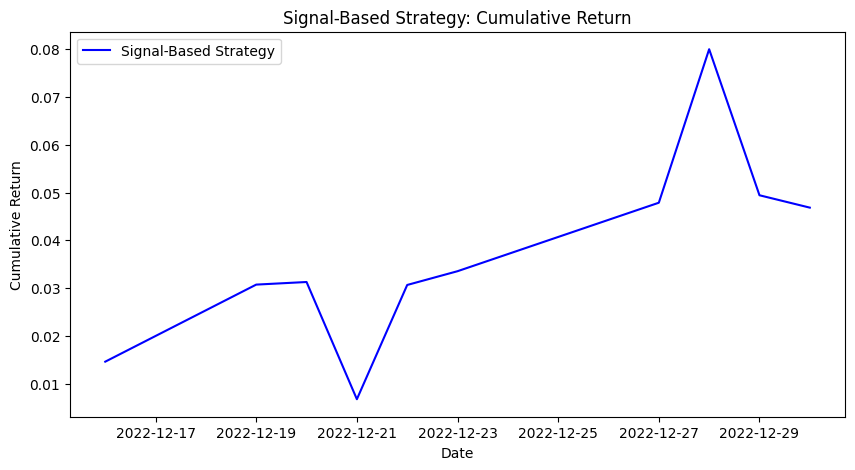

In [ ]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

# Signal generation
signal_based_data['Signal'] = (signal_based_data['SMA50'] > signal_based_data['SMA200']).astype(int) * 2 - 1

data= signal_based_data
# Accuracy calculation-
data['Correct'] = np.where((data['Signal'].shift(1) == 1) & (data['Close'].diff() > 0), 1, 0)
data['Correct'] = np.where((data['Signal'].shift(1) == -1) & (data['Close'].diff() < 0), 1, data['Correct'])
accuracy = data['Correct'].sum() / len(data)

# Cumulative return calculation
data['Strategy Return'] = data['Signal'].shift(1) * data['Close'].pct_change()
data['Cumulative Return'] = (1 + data['Strategy Return']).cumprod() - 1

print(f"Signal-Based Strategy Accuracy: {accuracy:.2%}")
print(f"Signal-Based Strategy Cumulative Return: {data['Cumulative Return'].iloc[-1]:.2%}")

# Plotting cumulative return
plt.figure(figsize=(10, 5))
plt.plot(data['Cumulative Return'], label='Signal-Based Strategy', color='blue')
plt.title("Signal-Based Strategy: Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

# PPO

In [3]:
!pip install stable-baselines3[extra]
!pip install shimmy

zsh:1: no matches found: stable-baselines3[extra]


In [ ]:
from stable_baselines3 import PPO
import gym
import numpy as np

class TradingEnv(gym.Env):
    def __init__(self, data):
        super(TradingEnv, self).__init__()
        self.data = data
        self.current_step = 0
        self.done = False

        # Define action space: Buy (1), Sell (0)
        self.action_space = gym.spaces.Discrete(2)

        # Define observation space: using normalized price and technical indicators
        self.observation_space = gym.spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(5,), 
            dtype=np.float32
        )

    def reset(self):
        self.current_step = 0
        self.done = False
        return self._get_observation()

    def _get_observation(self):
        # Get relevant features for observation (normalized)
        obs = np.array([
            self.data['Close'].iloc[self.current_step],
            self.data['SMA50'].iloc[self.current_step],
            self.data['SMA200'].iloc[self.current_step],
            self.data['Volume'].iloc[self.current_step],
            self.data['Return'].iloc[self.current_step]
        ])
        obs = np.nan_to_num(obs, nan= 0.0)
        return obs.astype(np.float32)

    def step(self, action):
        # Update the current step
        self.current_step += 1

        # Check if the episode is done
        if self.current_step >= len(self.data) - 1:
            self.done = True

        # Calculate the price change
        price_change = self.data['Return'].iloc[self.current_step]
    
        # Calculate the reward based on the action
        if action == 1:  # Buy
            reward = price_change
        elif action == 0:  # Sell
            reward = -1 * price_change

        # Get the next observation
        obs = self._get_observation()

        # Determine actual movement (1 if price goes up, 0 if down or equal)
        actual_movement = int(price_change > 0)
        return obs, reward, self.done, {"actual_movement": actual_movement}


# Create and train the PPO model
env = TradingEnv(model_based_data[:len(X_train)])
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=1000)

# Test the model and calculate accuracy and cumulative return
obs = env.reset()
correct_predictions = 0
total_predictions = 0
cumulative_return = 0

for _ in range(1000):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)

    # Accuracy tracking
    actual_movement = info.get('actual_movement')
    if action == actual_movement:
        correct_predictions += 1
    total_predictions += 1
    
    # Cumulative return
    cumulative_return += reward

    if done:
        obs = env.reset()

accuracy = correct_predictions / total_predictions
print(f"Model-Based Strategy Accuracy: {accuracy:.2%}")
print(f"Model-Based Strategy Cumulative Return: {(cumulative_return):.2%}")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 40       |
|    ep_rew_mean     | -0.0248  |
| time/              |          |
|    fps             | 3861     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
Model-Based Strategy Accuracy: 47.50%
Model-Based Strategy Cumulative Return: 29.24%
